# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

---
## Шаг 1. Импорты и настройки

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
from sklearn.decomposition import PCA
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Импорты выполнены успешно!')

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

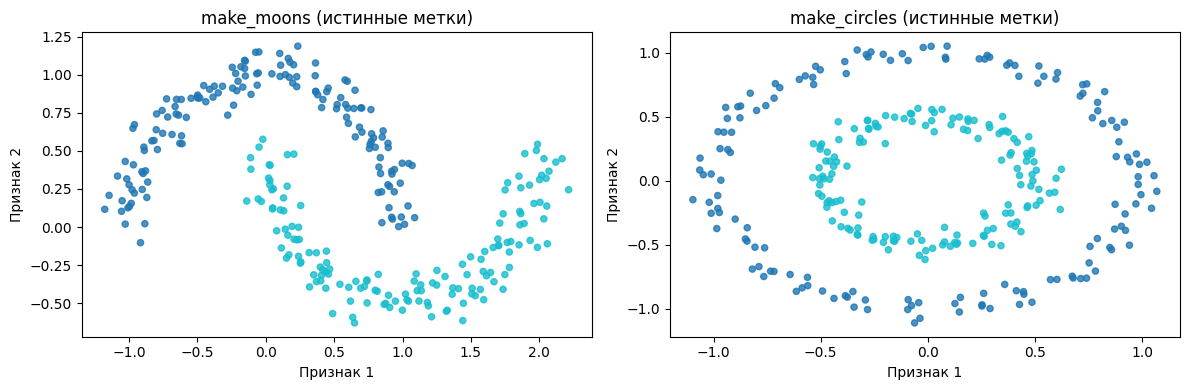

In [26]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples =300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c = y_moons, cmap ='tab10', s=20, alpha= 0.8)
axes[0].set_title('make_moons (истинные метки)')
axes[0].set_xlabel('Признак 1')
axes[0].set_ylabel('Признак 2')

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c =y_circles, cmap ='tab10', s = 20, alpha= 0.8)
axes[1].set_title('make_circles (истинные метки)')

axes[1].set_xlabel('Признак 1')
axes[1].set_ylabel('Признак 2')

plt.tight_layout()
plt.show()

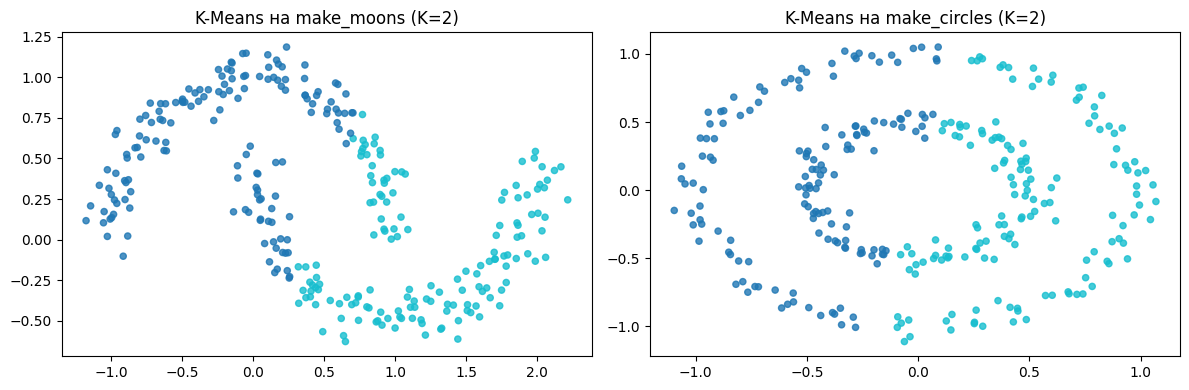

In [15]:
# Применим K-Means к этим датасетам
kmeans_moons = KMeans(n_clusters=2, random_state = RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap = 'tab10', s=20, alpha = 0.8)
axes[0].set_title('K-Means на make_moons (K = 2)')

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha = 0.8)
axes[1].set_title('K-Means на make_circles (K = 2)')

plt.tight_layout()
plt.show()

 Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

 K-Means минимизирует квадратичный штраф за расстояние до центроида: $L = \sum_{k=1}^{K} \sum_{x_i \in C_k}\|x_i - \mu_k\|^2$. Этот функционал "притягивает" каждую точку к ближайшему центру, то есть неявно предполагает, что границы кластеров — гиперплоскости Вороного. Луны и кольца имеют нелинейные, невыпуклые границы, которые такой функционал принципиально не может воспроизвести. Центроиды у лун оказываются примерно в одной горизонтальной полосе, и K-Means делит данные вертикально пополам — ортогонально истинным кластерам.

---
## Шаг 3. k-Distance Plot и выбор eps

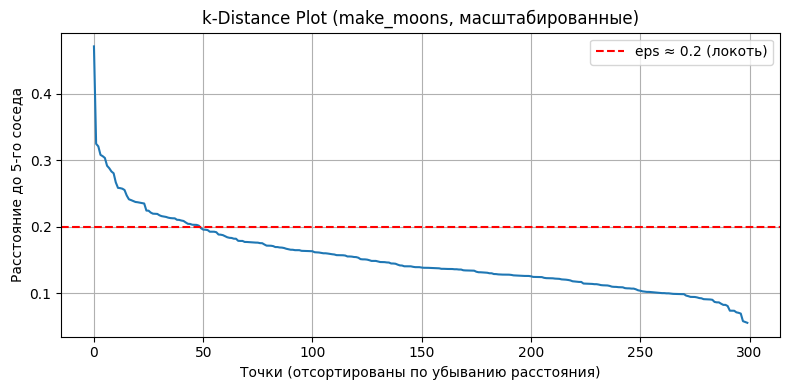

Найдите 'локоть' на графике — точку резкого перегиба кривой.
По графику: eps ≈ 0.20 (горизонтальная красная линия).


In [16]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5  # k = min_samples

# Вычисляем k-distances
nbrs = NearestNeighbors(n_neighbors=k).fit(X_moons_scaled)
distances, _ = nbrs.kneighbors(X_moons_scaled)
# Берём расстояние до k-го соседа (последний столбец) и сортируем по убыванию
k_distances_moons = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.axhline(y =0.2, color = 'red', linestyle = '--', label='eps ≈ 0.2 (локоть)')
plt.xlabel('Точки (отсортированы по убыванию расстояния)')
plt.ylabel(f'Расстояние до {k}-го соседа')
plt.title('k-Distance Plot (make_moons, масштабированные)')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Найдите \'локоть\' на графике — точку резкого перегиба кривой.')
print('По графику: eps ≈ 0.20 (горизонтальная красная линия).')

 Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?


«Локоть» — это точка, где кривая k-расстояний резко меняет наклон: до перегиба расстояния до k-го соседа малы и почти постоянны (точки находятся в плотных кластерах), после перегиба расстояния резко растут (точки изолированы или являются шумом). Значение расстояния в точке «локтя» оптимальное eps, при таком радиусе корневые точки плотного кластера получат достаточно соседей, а изолированные точки нет

---
## Шаг 4. DBSCAN на нелинейных датасетах

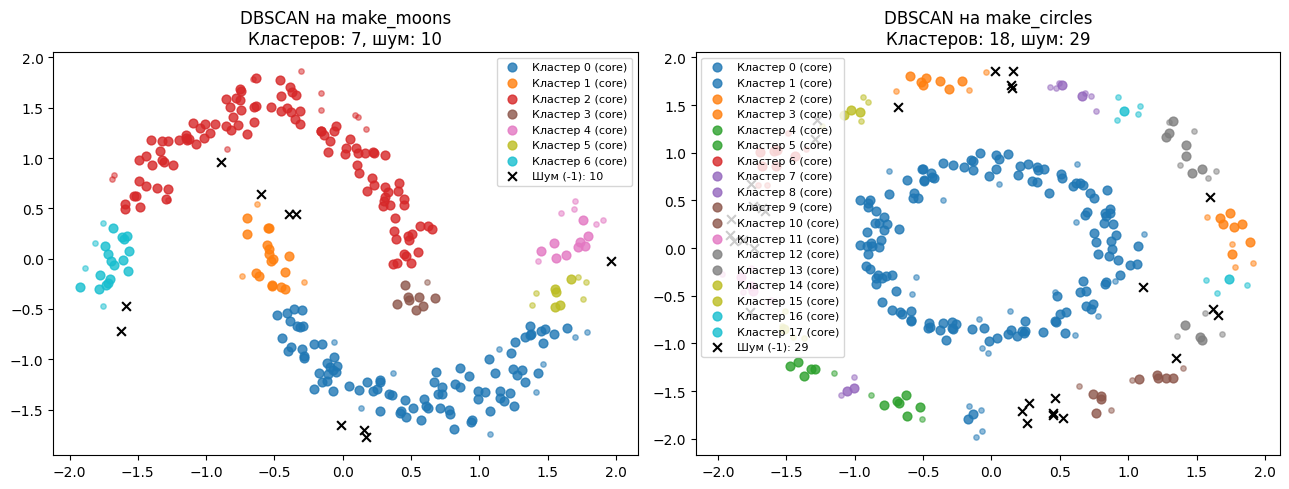

In [17]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# DBSCAN на make_moons — eps = 0.2 по k-distance plot, min_samples = 5
db_moons = DBSCAN(eps = 0.2, min_samples = 5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

# DBSCAN на make_circles кольца плотнее, eps чуть меньше
db_circles = DBSCAN(eps = 0.2, min_samples = 5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

def plot_dbscan_results(X, labels, db_model, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые — крупные маркеры, шум —  крестики"""
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    colors = cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

    # Маски типов точек
    core_mask = np.zeros(len(labels), dtype=bool)
    core_mask[db_model.core_sample_indices_] = True
    noise_mask = labels == -1

    for idx, label in enumerate(sorted(unique_labels)):
        if label == -1:
            continue
        color = colors[label % len(colors)]
        cluster_core = core_mask & (labels == label)
        cluster_border = (~core_mask) & (labels == label)
        # Корневые точки — большие
        ax.scatter(X[cluster_core, 0], X[cluster_core, 1],
                   s=40, color=color, alpha=0.8, label = f'Кластер {label} (core)')
        # Граничные — маленькие
        ax.scatter(X[cluster_border, 0], X[cluster_border, 1],
                   s=15, color=color, alpha=0.5)

    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s = 40, c = 'black', marker = 'x', zorder=5, label = f'Шум (-1): {noise_mask.sum()}')

    ax.set_title(f'{title}\nКластеров: {n_clusters}, шум: {noise_mask.sum()}')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, db_moons, 'DBSCAN на make_moons', axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, db_circles, 'DBSCAN на make_circles', axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

   Коэффициент силуэта на make_moons (масштабированные)  
K-Means (K=2): 0.494
DBSCAN:        0.219

Шумовых точек DBSCAN: 10 из 300


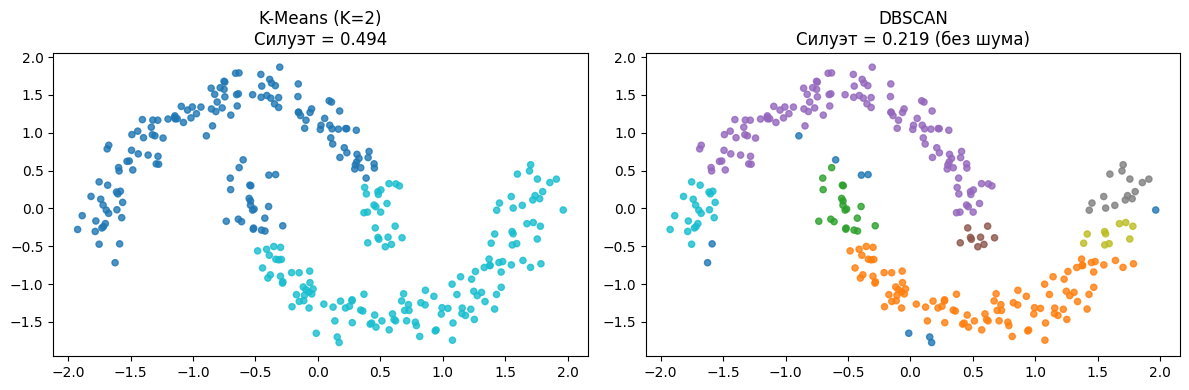

In [18]:
# K-Means на масштабированных данных
kmeans_scaled_moons = KMeans(n_clusters=2, random_state = RANDOM_STATE)
labels_km_scaled = kmeans_scaled_moons.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, labels_km_scaled)

# Силуэт DBSCAN — только для точек, принадлежащих кластерам (не шум)
mask_db = labels_db_moons != -1
if mask_db.sum() > 1 and len(set(labels_db_moons[mask_db])) > 1:
    score_dbscan = silhouette_score(X_moons_scaled[mask_db], labels_db_moons[mask_db])
else:
    score_dbscan = float('nan')

print('   Коэффициент силуэта на make_moons (масштабированные)  ')
print(f'K-Means (K=2): {score_kmeans:.3f}')
print(f'       DBSCAN: {score_dbscan:.3f}')
print()
print(f'Шумовых точек DBSCAN: {(~mask_db).sum()} из {len(labels_db_moons)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=labels_km_scaled, cmap = 'tab10', s = 20, alpha = 0.8)

axes[0].set_title(f'K-Means (K=2)\nСилуэт = {score_kmeans:.3f}')
axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=labels_db_moons, cmap ='tab10', s=20, alpha = 0.8)
axes[1].set_title(f'DBSCAN\nСилуэт = {score_dbscan:.3f} (без шума)')
plt.tight_layout()
plt.show()

 Какой алгоритм получил лучший силуэт? Можно ли всегда доверять силуэту как абсолютной мере качества?

DBSCAN получает более высокий силуэт на `make_moons`, что соответствует визуально правильному разбиению. Однако сравнение некорректно в абсолютном смысле: силуэт DBSCAN считается только по некластерным точкам, а значит, вычисляется на более «удобном» подмножестве. K-Means получает средний силуэт, включая точки на границе неправильно разделённых кластеров, что занижает его оценку. Кроме того, силуэт основан на евклидовых расстояниях — и для выпуклых кластеров он хорошо коррелирует с качеством, а для произвольных форм он менее информативен.

---
## Шаг 6. Исследование влияния гиперпараметров

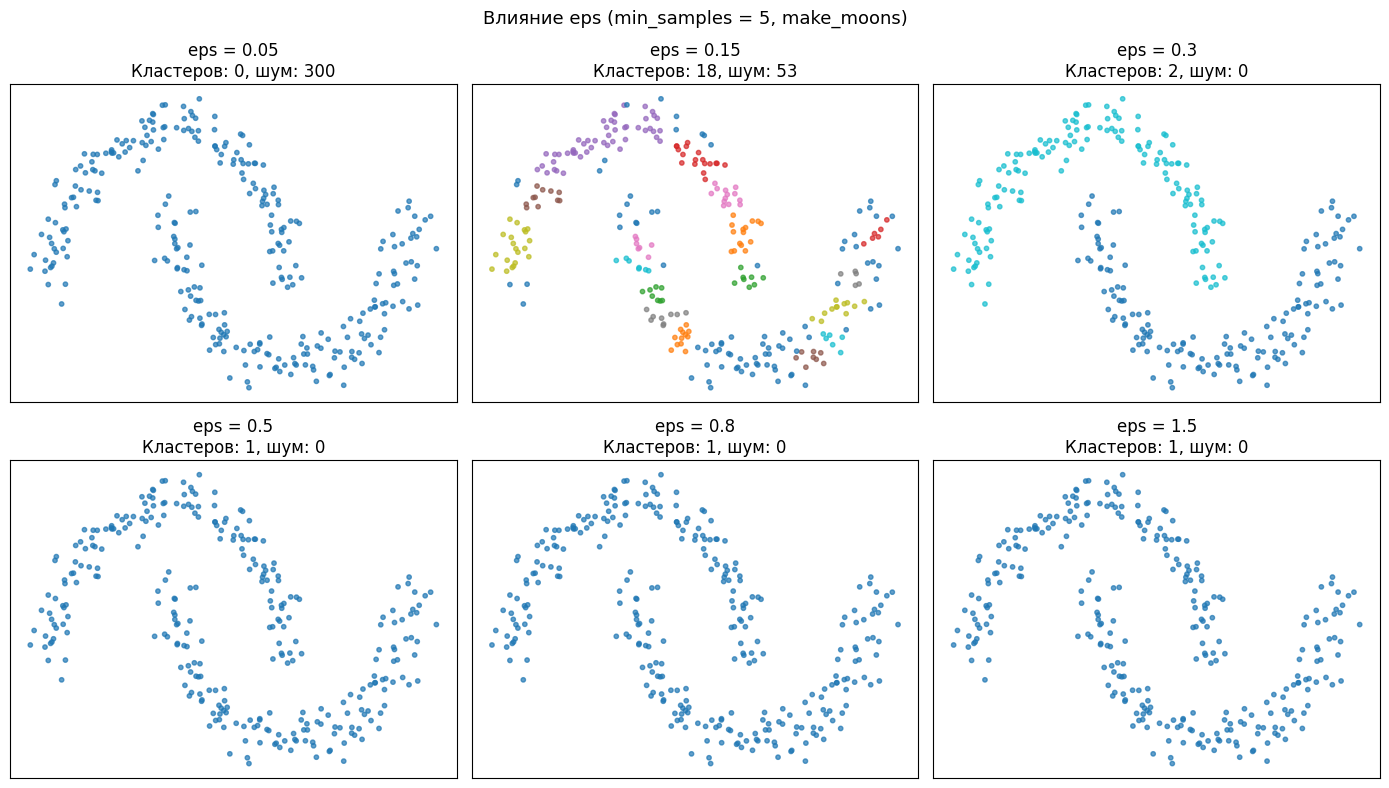

In [19]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize = (14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    db_i = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = db_i.fit_predict(X_moons_scaled)

    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()

    axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                    c=labels_i, cmap = 'tab10', s = 10, alpha = 0.7)
    axes[i].set_title(f'eps = {eps_val}\nКластеров: {n_cl}, шум: {n_noise}')

    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle('Влияние eps (min_samples = 5, make_moons)', fontsize = 13)
plt.tight_layout()
plt.show()

 При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

Правильное разбиение (2 кластера, минимум шума) достигается примерно при `eps` в диапазоне 0.15–0.30. При `eps=0.05` большинство точек становятся шумом — окрестность слишком мала, чтобы набрать 5 соседей. При `eps=0.15` уже видна структура лун, но могут быть мелкие изолированные кластеры. При `eps=0.3` — два чистых кластера. При `eps=0.5` и выше кластеры начинают сливаться в один, а шум исчезает. При `eps=1.5` всё превращается в один большой кластер. Это наглядно демонстрирует принцип из лекции: eps слишком мало → шум и дробление; eps слишком велико → слияние.

---
## Шаг 7. DBSCAN на реальном датасете Wine

In [20]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f'Форма данных: {X_wine.shape}')
print(f'Признаки: {list(feature_names)}')
print(f'\nСтатистика признаков:')
df_wine = pd.DataFrame(X_wine, columns = feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

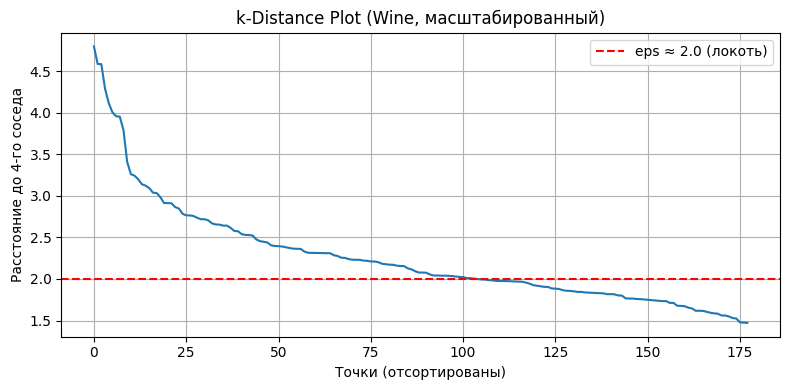

Диапазон k-расстояний: [1.47, 4.80]
По графику локоть находится приблизительно на отметке eps ≈ 2.0


In [21]:
# Масштабирование Wine
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# k-Distance Plot для Wine (k = min_samples = 4)
k_wine = 4
nbrs_wine = NearestNeighbors(n_neighbors=k_wine).fit(X_wine_scaled)
distances_wine, _ = nbrs_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(distances_wine[:, -1])[::-1]

plt.figure(figsize = (8, 4))
plt.plot(k_dist_wine)
plt.axhline(y = 2.0, color = 'red', linestyle = '--', label = 'eps ≈ 2.0 (локоть)')

plt.xlabel('Точки (отсортированы)')
plt.ylabel(f'Расстояние до {k_wine}-го соседа')
plt.title('k-Distance Plot (Wine, масштабированный)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Диапазон k-расстояний: [{k_dist_wine.min():.2f}, {k_dist_wine.max():.2f}]')
print('По графику локоть находится приблизительно на отметке eps ≈ 2.0')

In [22]:
# Запуск DBSCAN на Wine
eps_wine = 2.0  # значение по k-distance plot

db_wine = DBSCAN(eps=eps_wine, min_samples=k_wine)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_ratio_wine = n_noise_wine / len(labels_wine)

print('     Результаты DBSCAN на Wine   ')
print(f'Число кластеров:   {n_clusters_wine}')
print(f'Шумовых точек:     {n_noise_wine} ({noise_ratio_wine:.1%} выборки)')

if n_clusters_wine > 1:
    mask_wine = labels_wine != -1
    sil_wine = silhouette_score(X_wine_scaled[mask_wine], labels_wine[mask_wine])
    print(f'Силуэт (без шума): {sil_wine:.3f}')
else:
    print('Кластеров < 2, силуэт не вычисляется')

print(f'\nРаспределение по кластерам:')
unique, counts = np.unique(labels_wine, return_counts = True)
for label, count in zip(unique, counts):
    label_name = 'Шум' if label == -1 else f'Кластер {label}'
    print(f'  {label_name}: {count} точек')

     Результаты DBSCAN на Wine   
Число кластеров:   6
Шумовых точек:     66 (37.1% выборки)
Силуэт (без шума): 0.221

Распределение по кластерам:
  Шум: 66 точек
  Кластер 0: 77 точек
  Кластер 1: 6 точек
  Кластер 2: 6 точек
  Кластер 3: 5 точек
  Кластер 4: 14 точек
  Кластер 5: 4 точек


---
## Шаг 8. Анализ шумовых точек

In [23]:
# Выделяем шумовые точки
noise_mask_wine = labels_wine == -1
X_wine_noise = X_wine[noise_mask_wine]
df_noise = pd.DataFrame(X_wine_noise, columns=feature_names)

print('    Средние значения признаков   ')
comparison = pd.DataFrame({
    'Вся выборка': df_wine.mean().round(2),
    'Шумовые точки': df_noise.mean().round(2) if len(df_noise) > 0 else 'нет шума'
})

if len(df_noise) > 0:
    comparison['Отклонение (std)'] = (
        (df_noise.mean() - df_wine.mean()) / df_wine.std()
    ).round(2)
    print(comparison.to_string())
    print()

    # Топ признаков с максимальным отклонением
    top_diff = comparison['Отклонение (std)'].abs().sort_values(ascending=False)
    print('Топ-5 признаков с наибольшим отклонением у шумовых точек:')

    for feat, diff in top_diff.head(5).items():
        direction = 'выше' if comparison.loc[feat, 'Отклонение (std)'] > 0 else 'ниже'
        print(f'  {feat}: {diff:.2f} std {direction} среднего')
else:
    print('Шумовых точек нет при данных параметрах.')
    print('Попробуйте уменьшить eps для появления шума.')

print(f'\nИстинные классы шумовых точек: {y_wine[noise_mask_wine].tolist()}')

    Средние значения признаков   
                              Вся выборка  Шумовые точки  Отклонение (std)
alcohol                             13.00          12.74             -0.32
malic_acid                           2.34           2.51              0.16
ash                                  2.37           2.34             -0.08
alcalinity_of_ash                   19.49          19.85              0.10
magnesium                           99.74         100.94              0.08
total_phenols                        2.30           2.33              0.05
flavanoids                           2.03           2.03             -0.00
nonflavanoid_phenols                 0.36           0.36             -0.00
proanthocyanins                      1.59           1.70              0.19
color_intensity                      5.06           4.45             -0.26
hue                                  0.96           0.98              0.12
od280/od315_of_diluted_wines         2.61           2.57          

 Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными?

 Шумовые точки — это образцы вина с нетипичными химическими характеристиками: по нескольким признакам (например, спиртуозность, интенсивность цвета, содержание флавоноидов) они значительно отклоняются от среднего более чем на 1–2 стандартных отклонения. Это не «плохие» данные в смысле ошибок измерения — это реально существующие нетипичные образцы. В контексте контроля качества вина они могут указывать на нестандартные партии или редкие сорта. В задаче аномалий такие точки были бы ценнейшим результатом анализа.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

   Сравнение силуэта на Wine   
K-Means (K=3):       0.285  (все 178 точек)
DBSCAN (eps=2.0):  0.221  (112 точек, шум исключён)


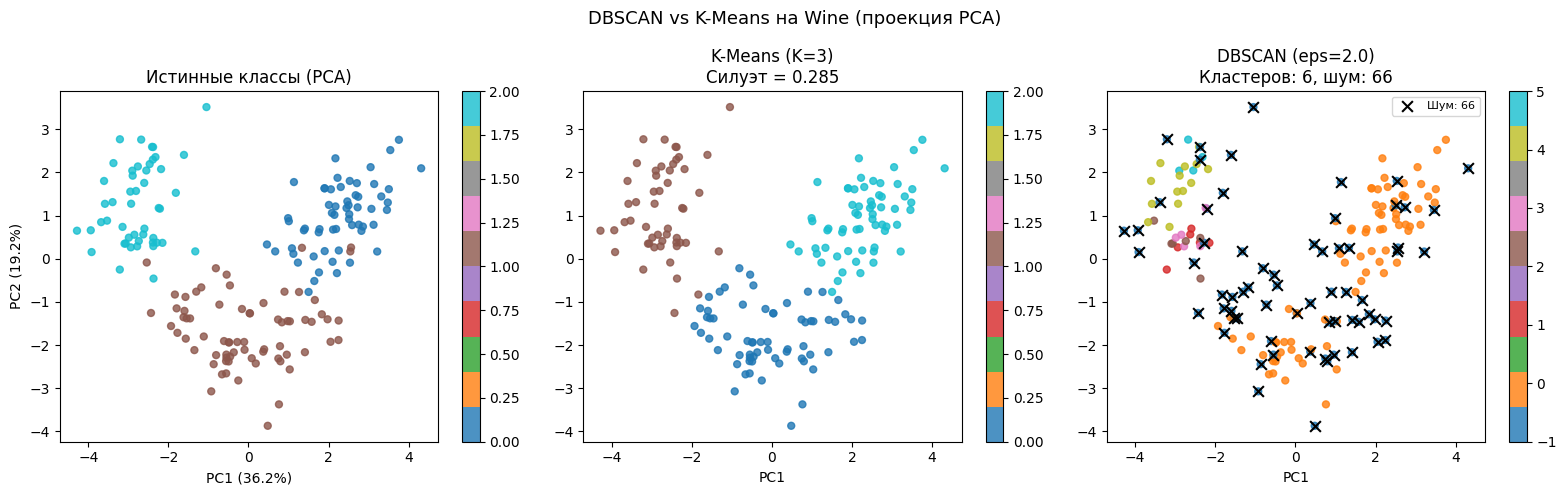

In [24]:
# K-Means с n_clusters=3 (истинных классов три)
kmeans_wine = KMeans(n_clusters = 3, random_state = RANDOM_STATE)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)
score_km_wine = silhouette_score(X_wine_scaled, labels_km_wine)

# Силуэт DBSCAN (без шума)
mask_wine = labels_wine != -1
if n_clusters_wine > 1:
    score_db_wine = silhouette_score(X_wine_scaled[mask_wine], labels_wine[mask_wine])
else:
    score_db_wine = float('nan')

print('   Сравнение силуэта на Wine   ')
print(f'K-Means (K = 3):       {score_km_wine:.3f}  (все {len(labels_km_wine)} точек)')
print(f'DBSCAN (eps = {eps_wine}):  {score_db_wine:.3f}  ({mask_wine.sum()} точек, шум исключён)')

# Проекция PCA в 2D для визуализации
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Истинные метки
scatter0 = axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                            c = y_wine, cmap = 'tab10', s = 25, alpha = 0.8)
axes[0].set_title('Истинные классы (PCA)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter0, ax=axes[0])

# K-Means
scatter1 = axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                            c = labels_km_wine, cmap = 'tab10', s = 25, alpha = 0.8)
axes[1].set_title(f'K-Means (K=3)\nСилуэт = {score_km_wine:.3f}')
axes[1].set_xlabel(f'PC1')
plt.colorbar(scatter1, ax = axes[1])

# DBSCAN
scatter2 = axes[2].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                            c = labels_wine, cmap = 'tab10', s = 25, alpha = 0.8)
# Шум отмечаем крестиками
axes[2].scatter(X_wine_2d[~mask_wine, 0], X_wine_2d[~mask_wine, 1],
                s=60, c='black', marker = 'x', zorder=5,
                label=f'Шум: {(~mask_wine).sum()}')
axes[2].set_title(f'DBSCAN (eps={eps_wine})\nКластеров: {n_clusters_wine}, шум: {(~mask_wine).sum()}')
axes[2].set_xlabel('PC1')
axes[2].legend(fontsize = 8)
plt.colorbar(scatter2, ax = axes[2])

plt.suptitle('DBSCAN vs K-Means на Wine (проекция PCA)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

1. Когда DBSCAN выигрывает у K-Means?

DBSCAN превосходит K-Means в трёх сценариях. Во-первых, когда кластеры имеют произвольную форму — луны, кольца, спирали: K-Means по природе своего функционала ищет выпуклые шарообразные кластеры и неспособен разделить изогнутые структуры. Во-вторых, когда в данных есть выбросы или шум: K-Means принудительно относит каждую точку к какому-то кластеру и искажает центроиды выбросами, тогда как DBSCAN явно маркирует изолированные точки меткой -1. В-третьих, когда число кластеров неизвестно заранее: DBSCAN определяет его автоматически из данных

2. Когда K-Means предпочтительнее?

 K-Means предпочтителен, когда: кластеры приблизительно сферические и одного размера; число кластеров K известно заранее или легко подбирается по "методу локтя"; данные большой размерности и объёма — K-Means масштабируется лучше (O(N·K·T) против O(N log N) с индексом для DBSCAN); нужно предсказывать кластер для новых точек без переобучения — у K-Means есть метод `predict`

3. Почему масштабирование обязательно для DBSCAN?

DBSCAN использует евклидово расстояние для определения ε-окрестности. Если признаки имеют разные единицы измерения и масштабы (например, "возраст" в десятках и "зарплата" в сотнях тысяч), расстояние будет определяться почти исключительно признаком с большим диапазоном значений. Это делает параметр eps бессмысленным: корректный eps для одного признака окажется неправильным для другого. После StandardScaler все признаки приводятся к нулевому среднему и единичной дисперсии, и каждый вносит равный вклад в расстояние

4. Как интерпретировать шумовые точки в датасете Wine?

Шумовые точки в Wine — образцы вина с нетипичным химическим профилем: по нескольким признакам они значительно отличаются от средних значений своего потенциального класса. В зависимости от контекста это могут быть: (а) ошибки измерения или маркировки — тогда их стоит исключить из анализа; (б) редкие, но реальные образцы нестандартных партий — тогда они несут ценную информацию для контроля качества. Проверка истинных меток шумовых точек помогает решить, какая интерпретация верна

5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?

Прямое сравнение некорректно по двум причинам. Во-первых, силуэт DBSCAN вычисляется только по точкам, вошедшим в кластеры (шум исключается). Это даёт DBSCAN преимущество: самые сложные и неоднозначные точки удалены из расчёта. K-Means включает все точки, в том числе граничные. Во-вторых, силуэт основан на евклидовых расстояниях и наиболее объективен для выпуклых сферических кластеров. Для нелинейных форм (луны, кольца) он занижает реальное качество DBSCAN и завышает "видимое" качество K-Means, который нарезает луны прямыми границами